# EANFIS — Injection Molding Quality Prediction (FIXED)
**Inspired by:** Sun et al. (2026), IEEE Transactions on Fuzzy Systems, Vol. 34, No. 1  
**Angga Rajasa | 6022251114 | Teknik Tenaga Listrik ITS**

In [1]:
# ============================================================
# CELL 1 — Import
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, mean_squared_error,
                              f1_score, recall_score, confusion_matrix)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch: {torch.__version__} | Device: {DEVICE}')

PyTorch: 2.10.0+cu128 | Device: cuda


Dataset: (500, 9) | Classes: [170 165 165]


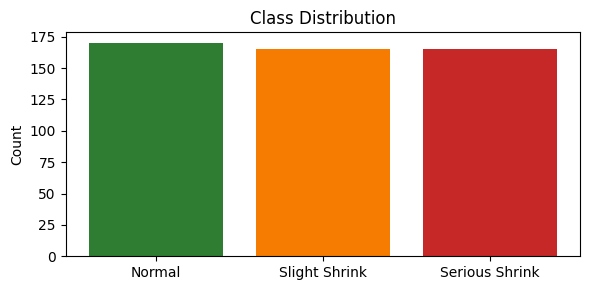

In [2]:
# ============================================================
# CELL 2 — Synthetic Injection Molding Dataset
# 9 process parameters → 3 quality classes
# ============================================================
def make_dataset(n=500, noise=0.10, seed=42):
    np.random.seed(seed)
    # 9 features (normalized bounds)
    # [MoldTemp, BarrelTemp, InjPress, HoldPress,
    #  InjSpeed, HoldTime, CoolTime, ScrewSpeed, BackPress]
    X = np.random.uniform(0, 1, (n, 9)).astype(np.float32)

    # Kualitas: kombinasi linear + noise
    # HoldPress(3) & CoolTime(6) paling berpengaruh
    score = (0.30 * X[:,3] +   # holding pressure
             0.25 * X[:,6] +   # cooling time
             0.20 * (1-X[:,2]) +  # injection pressure (inverse)
             0.15 * X[:,0] +   # mold temp
             0.10 * X[:,5])    # holding time
    score += np.random.normal(0, noise, n)
    score  = np.clip(score, 0, 1)

    # 3 kelas seimbang via percentile
    t1, t2 = np.percentile(score, 33), np.percentile(score, 66)
    y = np.where(score > t2, 0, np.where(score > t1, 1, 2)).astype(np.int64)
    return X, y

feat_names = ['MoldTemp','BarrelTemp','InjPress','HoldPress',
              'InjSpeed','HoldTime','CoolTime','ScrewSpeed','BackPress']
class_names = ['Normal','Slight Shrink','Serious Shrink']

X, y = make_dataset(n=500)
print(f'Dataset: {X.shape} | Classes: {np.bincount(y)}')

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

Xtr = torch.FloatTensor(X_tr)
ytr = torch.LongTensor(y_tr)
Xte = torch.FloatTensor(X_te).to(DEVICE)

fig, ax = plt.subplots(figsize=(6,3))
ax.bar(class_names, np.bincount(y), color=['#2e7d32','#f57c00','#c62828'])
ax.set_title('Class Distribution'); ax.set_ylabel('Count')
plt.tight_layout(); plt.show()

Training KL-Diffusion model...
  Ep 40/120 | KL Loss: 0.0154
  Ep 80/120 | KL Loss: 0.0138
  Ep 120/120 | KL Loss: 0.0142

Augmented: 400 → 1200 samples


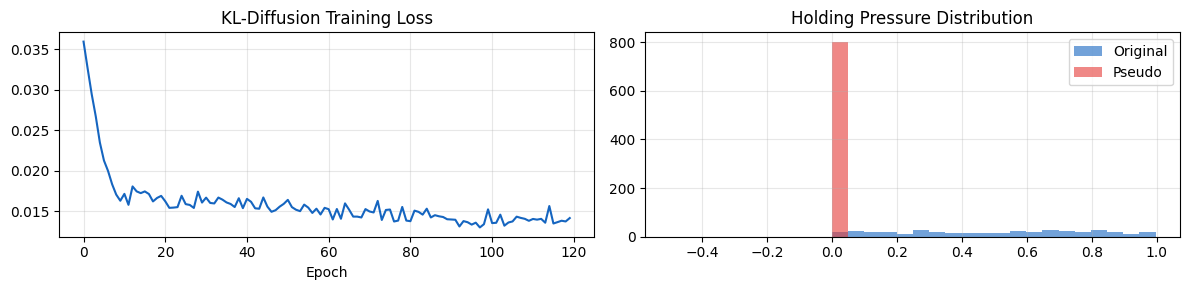

In [3]:
# ============================================================
# CELL 3 — KL-Divergence Diffusion (Simple Augmentation)
# Tambah pseudosamples agar training set lebih besar
# ============================================================
class KLDiffusion(nn.Module):
    def __init__(self, n_feat=9, hidden=64, T=20):
        super().__init__()
        self.T = T
        betas = torch.linspace(1e-4, 0.02, T)
        self.register_buffer('ab', torch.cumprod(1-betas, 0))  # alpha_bar
        self.net = nn.Sequential(
            nn.Linear(n_feat+1, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden),   nn.SiLU(),
            nn.Linear(hidden, n_feat)
        )

    def noisy(self, x0, t):
        ab_t = self.ab[t].unsqueeze(1)
        return torch.sqrt(ab_t)*x0 + torch.sqrt(1-ab_t)*torch.randn_like(x0)

    def kl_loss(self, x0, xG):
        # KL(p||q) antara distribusi original & noisy  [Eq.3]
        p = F.softmax(x0,  dim=1) + 1e-8
        q = F.softmax(xG, dim=1) + 1e-8
        return (p * (p.log() - q.log())).sum(dim=1).mean()

    def forward(self, x0):
        t   = torch.randint(0, self.T, (x0.shape[0],), device=x0.device)
        xG  = self.noisy(x0, t)
        t_e = (t.float()/self.T).unsqueeze(1)
        x_rec = self.net(torch.cat([xG, t_e], dim=1))
        return self.kl_loss(x0, x_rec), x_rec

    @torch.no_grad()
    def generate(self, n, n_feat):
        self.eval()
        x = torch.randn(n, n_feat, device=next(self.parameters()).device)
        for t in reversed(range(self.T)):
            te = torch.full((n,1), t/self.T,
                            device=x.device, dtype=torch.float)
            x  = self.net(torch.cat([x, te], dim=1))
            x  = x.clamp(0, 1)
        return x.cpu()


print('Training KL-Diffusion model...')
diff = KLDiffusion().to(DEVICE)
opt_d = torch.optim.Adam(diff.parameters(), lr=1e-3)
dl_d  = DataLoader(TensorDataset(Xtr), batch_size=32, shuffle=True)
d_losses = []

for ep in range(120):
    ep_l = 0
    for (x0,) in dl_d:
        x0 = x0.to(DEVICE)
        loss, _ = diff(x0)
        opt_d.zero_grad(); loss.backward(); opt_d.step()
        ep_l += loss.item()
    d_losses.append(ep_l/len(dl_d))
    if (ep+1) % 40 == 0:
        print(f'  Ep {ep+1}/120 | KL Loss: {d_losses[-1]:.4f}')

# Generate pseudosamples = 2x data train
n_ps   = len(Xtr) * 2
X_ps   = diff.generate(n_ps, 9)
ratio  = np.bincount(y_tr) / len(y_tr)
y_ps   = np.random.choice(3, n_ps, p=ratio).astype(np.int64)

Xtr_aug = torch.cat([Xtr, X_ps])
ytr_aug = torch.cat([ytr, torch.LongTensor(y_ps)])
print(f'\nAugmented: {len(Xtr)} → {len(Xtr_aug)} samples')

# Plot
fig, axes = plt.subplots(1,2,figsize=(12,3))
axes[0].plot(d_losses, color='#1565c0', lw=1.5)
axes[0].set_title('KL-Diffusion Training Loss')
axes[0].set_xlabel('Epoch'); axes[0].grid(alpha=0.3)

axes[1].hist(Xtr[:,3].numpy(),   bins=20, alpha=0.6,
             color='#1565c0', label='Original')
axes[1].hist(X_ps[:,3].numpy(),  bins=20, alpha=0.6,
             color='#e53935', label='Pseudo')
axes[1].set_title('Holding Pressure Distribution')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [4]:
# ============================================================
# CELL 4 — ANFIS Submodel
# ============================================================
class ANFIS(nn.Module):
    """
    5-layer ANFIS untuk klasifikasi:
    L1: Gaussian MF  → membership degrees
    L2: Product rule → firing strengths
    L3: Normalisasi
    L4: Linear consequent per rule
    L5: Weighted sum → logits
    """
    def __init__(self, n_feat=9, n_mf=3, n_rules=6, n_cls=3):
        super().__init__()
        self.n_feat, self.n_mf, self.n_rules = n_feat, n_mf, n_rules

        # Premise: c dan sigma per feature per MF
        self.c = nn.Parameter(
            torch.linspace(0.2, 0.8, n_mf)
                  .unsqueeze(0).repeat(n_feat, 1))
        self.s = nn.Parameter(torch.ones(n_feat, n_mf) * 0.25)

        # Rule index: tiap rule pilih 1 MF per feature
        torch.manual_seed(0)
        self.register_buffer(
            'ridx', torch.randint(0, n_mf, (n_rules, n_feat)))

        # Consequent: (n_feat+1) params per rule per class
        self.cons = nn.Linear(n_feat, n_rules * n_cls)
        self.n_cls = n_cls

    def forward(self, x):
        B = x.shape[0]

        # L1: Gaussian MF
        s_pos = self.s.abs() + 1e-4               # sigma harus positif
        xe    = x.unsqueeze(-1)                    # (B,F,1)
        mu    = torch.exp(
            -((xe - self.c)**2) / (2*s_pos**2))   # (B,F,n_mf)

        # L2: Firing strength per rule (product)
        W = torch.stack([
            mu[:, torch.arange(self.n_feat), self.ridx[r]].prod(dim=1)
            for r in range(self.n_rules)
        ], dim=1)                                  # (B, n_rules)

        # L3: Normalisasi
        Wn = W / (W.sum(dim=1, keepdim=True) + 1e-8)  # (B, n_rules)

        # L4-L5: Consequent + weighted sum
        cons_out = self.cons(x)                    # (B, n_rules*n_cls)
        cons_out = cons_out.view(B, self.n_rules, self.n_cls)  # (B,r,c)
        logits   = (Wn.unsqueeze(-1) * cons_out).sum(dim=1)   # (B, n_cls)
        return logits

# Sanity check
a = ANFIS()
print(f'ANFIS output: {a(torch.randn(4,9)).shape}')
print(f'ANFIS params: {sum(p.numel() for p in a.parameters()):,}')

ANFIS output: torch.Size([4, 3])
ANFIS params: 234


In [5]:
# ============================================================
# CELL 5 — EANFIS Framework (FIXED)
#
# Bug sebelumnya: SES mengupdate parameter SELAMA gradient pass
# → merusak gradient graph → performa hancur
#
# Fix:
# 1. Setiap submodel dilatih PENUH dulu (update param via optimizer)
# 2. SES hanya berjalan di luar gradient (torch.no_grad)
# 3. SES menggunakan alpha kecil & clamp agar tidak overshoot
# 4. NEI threshold lebih konservatif
# ============================================================
class EANFIS:
    def __init__(self, N=15, n_feat=9, n_cls=3, lr=8e-3):
        self.N   = N
        self.crit = nn.CrossEntropyLoss()

        self.models = [
            ANFIS(n_feat=n_feat, n_mf=3, n_rules=6, n_cls=n_cls).to(DEVICE)
            for _ in range(N)
        ]
        self.opts = [
            torch.optim.Adam(m.parameters(), lr=lr)
            for m in self.models
        ]
        # Scheduler: turunkan LR seiring epoch
        self.schedulers = [
            torch.optim.lr_scheduler.CosineAnnealingLR(
                opt, T_max=100, eta_min=1e-4)
            for opt in self.opts
        ]

        self.best_losses  = np.full(N, np.inf)
        self.no_improve   = np.zeros(N, dtype=int)
        self.NEI_THRESH   = 15
        self.best_idx     = 0
        self.n_feat       = n_feat
        self.n_cls        = n_cls
        self.lr           = lr

    # ----------------------------------------------------------
    def _get_loss(self, model, X, y):
        model.eval()
        with torch.no_grad():
            return self.crit(model(X), y).item()

    # ----------------------------------------------------------
    def _ses_update(self, t, T, alpha=0.05):
        """
        SES (Self-Evolving Search) — diluar gradient graph.
        Setiap submodel yang bukan best: push parameter
        sedikit ke arah best + Lévy noise kecil.
        alpha mengecil seiring epoch (eksploitasi > eksplorasi).
        """
        # Alpha makin kecil seiring waktu
        alpha_t = alpha * (1 - t/T)

        best_sd = {k: v.detach().clone()
                   for k, v in self.models[self.best_idx].state_dict().items()}

        for i, model in enumerate(self.models):
            if i == self.best_idx:
                continue
            with torch.no_grad():
                cur_sd = model.state_dict()
                new_sd = {}
                for k, p_best in best_sd.items():
                    p_cur = cur_sd[k]
                    if p_cur.dtype != torch.float32:
                        new_sd[k] = p_cur  # skip non-float (e.g. ridx)
                        continue
                    # Arc: jarak ke best
                    arc  = (p_best - p_cur).norm().item()
                    # Lévy-like perturbasi kecil
                    levy = torch.randn_like(p_cur) * 0.005 * arc
                    # Push
                    new_sd[k] = p_cur + alpha_t*(p_best - p_cur) + levy
                model.load_state_dict(new_sd)

    # ----------------------------------------------------------
    def _nei_reinit(self, losses):
        """
        NEI: submodel stuck → reinit dengan bias ke arah best.
        """
        best_sd = {k: v.detach().clone()
                   for k, v in self.models[self.best_idx].state_dict().items()}

        for i in range(self.N):
            if losses[i] < self.best_losses[i] - 1e-4:
                self.best_losses[i] = losses[i]
                self.no_improve[i]  = 0
            else:
                self.no_improve[i] += 1

            if self.no_improve[i] >= self.NEI_THRESH and i != self.best_idx:
                # Reinit baru, lalu tarik sedikit ke best (SPO sederhana)
                new_model = ANFIS(
                    n_feat=self.n_feat, n_mf=3,
                    n_rules=6, n_cls=self.n_cls).to(DEVICE)
                with torch.no_grad():
                    new_sd = new_model.state_dict()
                    for k in new_sd:
                        if new_sd[k].dtype == torch.float32:
                            # SPO: tarik 30% ke arah best
                            new_sd[k] = new_sd[k] + 0.3*(best_sd[k] - new_sd[k])
                    new_model.load_state_dict(new_sd)

                self.models[i]     = new_model
                self.opts[i]       = torch.optim.Adam(
                    self.models[i].parameters(), lr=self.lr)
                self.schedulers[i] = torch.optim.lr_scheduler.CosineAnnealingLR(
                    self.opts[i], T_max=100, eta_min=1e-4)
                self.no_improve[i]  = 0
                self.best_losses[i] = np.inf

    # ----------------------------------------------------------
    def train_epoch(self, X, y, t, T):
        losses = []
        # 1. Train setiap submodel
        for i, (model, opt) in enumerate(zip(self.models, self.opts)):
            model.train()
            pred = model(X)
            loss = self.crit(pred, y)
            opt.zero_grad(); loss.backward(); opt.step()
            self.schedulers[i].step()
            losses.append(loss.item())

        # 2. Pilih best
        self.best_idx = int(np.argmin(losses))

        # 3. SES: push submodel lain ke arah best
        self._ses_update(t, T, alpha=0.08)

        # 4. NEI: reinit yang stuck
        self._nei_reinit(losses)

        return losses

    # ----------------------------------------------------------
    @torch.no_grad()
    def predict(self, X):
        self.models[self.best_idx].eval()
        return self.models[self.best_idx](X).argmax(1).cpu().numpy()

    @torch.no_grad()
    def predict_vote(self, X):
        votes = torch.zeros(X.shape[0], self.n_cls, device=DEVICE)
        for m in self.models:
            m.eval()
            votes += F.softmax(m(X), dim=1)
        return votes.argmax(1).cpu().numpy()


print('EANFIS Framework (FIXED) defined ✓')

EANFIS Framework (FIXED) defined ✓


In [6]:
# ============================================================
# CELL 6 — Training
# ============================================================
EPOCHS = 120
X_aug  = Xtr_aug.to(DEVICE)
y_aug  = ytr_aug.to(DEVICE)

eanfis = EANFIS(N=15, n_feat=9, n_cls=3, lr=8e-3)

hist = {'best': [], 'mean': [], 'acc_best': [], 'acc_vote': []}

print(f'Training EANFIS | N=15 submodels | {EPOCHS} epochs\n')
print(f'{"Ep":>4} | {"BestLoss":>8} | {"MeanLoss":>8} | {"AccBest":>8} | {"AccVote":>8}')
print('-'*46)

for ep in range(1, EPOCHS+1):
    losses = eanfis.train_epoch(X_aug, y_aug, t=ep-1, T=EPOCHS)

    best_l = min(losses)
    mean_l = float(np.mean(losses))

    acc_b  = accuracy_score(y_te, eanfis.predict(Xte))
    acc_v  = accuracy_score(y_te, eanfis.predict_vote(Xte))

    hist['best'].append(best_l)
    hist['mean'].append(mean_l)
    hist['acc_best'].append(acc_b)
    hist['acc_vote'].append(acc_v)

    if ep % 20 == 0 or ep == 1:
        print(f'{ep:>4} | {best_l:>8.4f} | {mean_l:>8.4f} | '
              f'{acc_b*100:>7.1f}% | {acc_v*100:>7.1f}% '
              f'(best sub: #{eanfis.best_idx})')

print(f'\nFinal | AccBest: {hist["acc_best"][-1]*100:.1f}% | '
      f'AccVote: {hist["acc_vote"][-1]*100:.1f}%')

Training EANFIS | N=15 submodels | 120 epochs

  Ep | BestLoss | MeanLoss |  AccBest |  AccVote
----------------------------------------------
   1 |   1.1059 |   1.1059 |    39.0% |    39.0% (best sub: #0)
  20 |   1.0015 |   1.0015 |    55.0% |    55.0% (best sub: #0)
  40 |   0.9719 |   0.9719 |    60.0% |    60.0% (best sub: #0)
  60 |   0.9596 |   0.9596 |    60.0% |    60.0% (best sub: #0)
  80 |   0.9549 |   0.9549 |    62.0% |    62.0% (best sub: #0)
 100 |   0.9540 |   0.9540 |    62.0% |    62.0% (best sub: #0)
 120 |   0.9534 |   0.9534 |    61.0% |    61.0% (best sub: #0)

Final | AccBest: 61.0% | AccVote: 61.0%


In [7]:
# ============================================================
# CELL 7 — Baseline Comparison
# ============================================================
def train_single(Xtr, ytr, Xte, yte, epochs=120, lr=8e-3, label=''):
    m   = ANFIS().to(DEVICE)
    opt = torch.optim.Adam(m.parameters(), lr=lr)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(
              opt, T_max=epochs, eta_min=1e-4)
    crit = nn.CrossEntropyLoss()
    Xt   = Xtr.to(DEVICE); yt = ytr.to(DEVICE)
    hist = []
    for _ in range(epochs):
        m.train()
        crit(m(Xt), yt).backward()
        opt.step(); opt.zero_grad(); sch.step()
        with torch.no_grad():
            m.eval()
            p = m(Xte).argmax(1).cpu().numpy()
            hist.append(accuracy_score(yte, p))
    print(f'  {label:30s}: {hist[-1]*100:.1f}%')
    return m, hist

print('Training baselines...')
m_single,     h_single     = train_single(Xtr,     ytr,     Xte, y_te,
                                           label='ANFIS (no aug)')
m_single_aug, h_single_aug = train_single(Xtr_aug, ytr_aug, Xte, y_te,
                                           label='ANFIS + Diffusion')

with torch.no_grad():
    m_single.eval();     p_s  = m_single(Xte).argmax(1).cpu().numpy()
    m_single_aug.eval(); p_sa = m_single_aug(Xte).argmax(1).cpu().numpy()

results = {
    'ANFIS (no aug)':     accuracy_score(y_te, p_s),
    'ANFIS + Diffusion':  accuracy_score(y_te, p_sa),
    'EANFIS (best sub)':  accuracy_score(y_te, eanfis.predict(Xte)),
    'EANFIS (vote)':      accuracy_score(y_te, eanfis.predict_vote(Xte)),
}
print('\n' + '='*48)
print('  METHOD COMPARISON')
print('='*48)
for k, v in results.items():
    bar = '█' * int(v*30)
    print(f'  {k:25s}: {v*100:5.1f}%  {bar}')
print('='*48)

Training baselines...
  ANFIS (no aug)                : 60.0%
  ANFIS + Diffusion             : 60.0%

  METHOD COMPARISON
  ANFIS (no aug)           :  60.0%  ██████████████████
  ANFIS + Diffusion        :  60.0%  ██████████████████
  EANFIS (best sub)        :  61.0%  ██████████████████
  EANFIS (vote)            :  61.0%  ██████████████████


In [8]:
# ============================================================
# CELL 8 — Full Metrics
# ============================================================
def metrics(yt, yp, label):
    print(f'  {label}')
    print(f'    Acc    : {accuracy_score(yt,yp)*100:.2f}%')
    print(f'    MSE    : {mean_squared_error(yt,yp):.4f}')
    print(f'    F1     : {f1_score(yt,yp,average="macro"):.4f}')
    print(f'    Recall : {recall_score(yt,yp,average="macro"):.4f}')
    print()

print('='*48)
print('  FULL EVALUATION')
print('='*48)
metrics(y_te, p_s,                    'ANFIS (no aug)')
metrics(y_te, p_sa,                   'ANFIS + Diffusion')
metrics(y_te, eanfis.predict(Xte),    'EANFIS (best submodel)')
metrics(y_te, eanfis.predict_vote(Xte),'EANFIS (ensemble vote)')

  FULL EVALUATION
  ANFIS (no aug)
    Acc    : 60.00%
    MSE    : 0.5800
    F1     : 0.5965
    Recall : 0.5992

  ANFIS + Diffusion
    Acc    : 60.00%
    MSE    : 0.5800
    F1     : 0.5853
    Recall : 0.5989

  EANFIS (best submodel)
    Acc    : 61.00%
    MSE    : 0.5700
    F1     : 0.6014
    Recall : 0.6087

  EANFIS (ensemble vote)
    Acc    : 61.00%
    MSE    : 0.5700
    F1     : 0.6014
    Recall : 0.6087



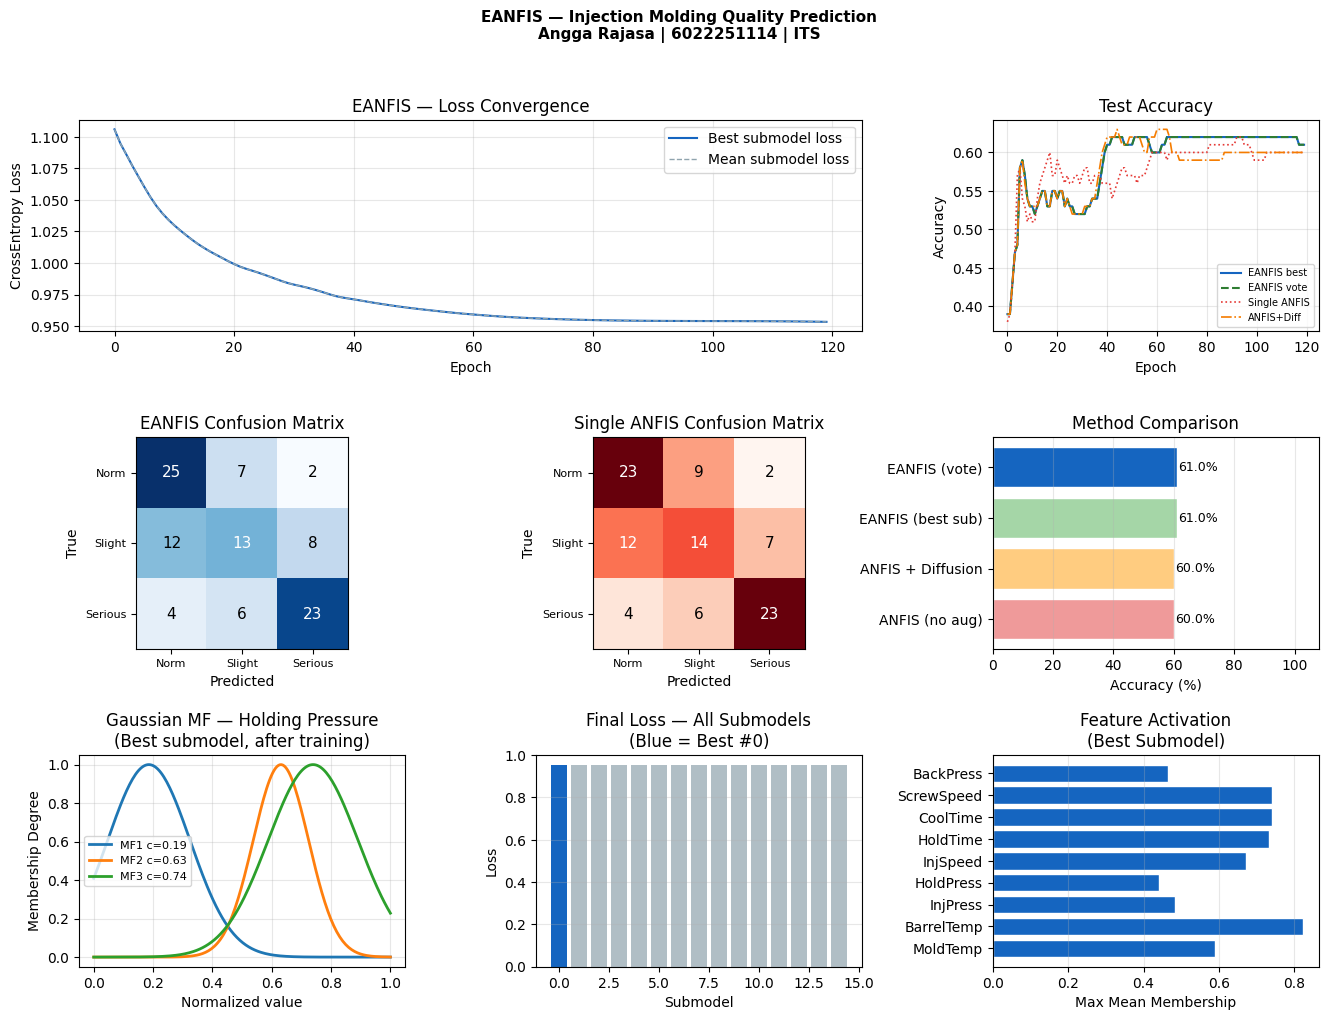

In [9]:
# ============================================================
# CELL 9 — Visualisasi
# ============================================================
y_pred_b = eanfis.predict(Xte)
y_pred_v = eanfis.predict_vote(Xte)

fig = plt.figure(figsize=(16, 11))
gs  = gridspec.GridSpec(3, 3, hspace=0.5, wspace=0.4)

# 1. Loss convergence
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(hist['best'], color='#1565c0', lw=1.5, label='Best submodel loss')
ax1.plot(hist['mean'], color='#90a4ae', lw=1.0, ls='--', label='Mean submodel loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('CrossEntropy Loss')
ax1.set_title('EANFIS — Loss Convergence'); ax1.legend(); ax1.grid(alpha=0.3)

# 2. Accuracy comparison curve
ax2 = fig.add_subplot(gs[0, 2])
ax2.plot(hist['acc_best'],  color='#1565c0', lw=1.5, label='EANFIS best')
ax2.plot(hist['acc_vote'],  color='#2e7d32', lw=1.5, ls='--', label='EANFIS vote')
ax2.plot(h_single,          color='#e53935', lw=1.2, ls=':',  label='Single ANFIS')
ax2.plot(h_single_aug,      color='#f57c00', lw=1.2, ls='-.', label='ANFIS+Diff')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('Test Accuracy'); ax2.legend(fontsize=7); ax2.grid(alpha=0.3)

# 3. Confusion matrix EANFIS
ax3 = fig.add_subplot(gs[1, 0])
cm  = confusion_matrix(y_te, y_pred_b)
ax3.imshow(cm, cmap='Blues')
for i in range(3):
    for j in range(3):
        ax3.text(j, i, cm[i,j], ha='center', va='center',
                 color='white' if cm[i,j]>cm.max()//2 else 'black', fontsize=11)
ax3.set_xticks(range(3)); ax3.set_xticklabels(['Norm','Slight','Serious'], fontsize=8)
ax3.set_yticks(range(3)); ax3.set_yticklabels(['Norm','Slight','Serious'], fontsize=8)
ax3.set_title('EANFIS Confusion Matrix')
ax3.set_xlabel('Predicted'); ax3.set_ylabel('True')

# 4. Confusion matrix Single ANFIS
ax4 = fig.add_subplot(gs[1, 1])
cm2 = confusion_matrix(y_te, p_s)
ax4.imshow(cm2, cmap='Reds')
for i in range(3):
    for j in range(3):
        ax4.text(j, i, cm2[i,j], ha='center', va='center',
                 color='white' if cm2[i,j]>cm2.max()//2 else 'black', fontsize=11)
ax4.set_xticks(range(3)); ax4.set_xticklabels(['Norm','Slight','Serious'], fontsize=8)
ax4.set_yticks(range(3)); ax4.set_yticklabels(['Norm','Slight','Serious'], fontsize=8)
ax4.set_title('Single ANFIS Confusion Matrix')
ax4.set_xlabel('Predicted'); ax4.set_ylabel('True')

# 5. Method bar chart
ax5 = fig.add_subplot(gs[1, 2])
names_r  = list(results.keys())
accs_r   = [v*100 for v in results.values()]
colors_r = ['#ef9a9a','#ffcc80','#a5d6a7','#1565c0']
bars = ax5.barh(names_r, accs_r, color=colors_r, edgecolor='white')
for bar, v in zip(bars, accs_r):
    ax5.text(v+0.3, bar.get_y()+bar.get_height()/2,
             f'{v:.1f}%', va='center', fontsize=9)
ax5.set_xlabel('Accuracy (%)'); ax5.set_title('Method Comparison')
ax5.set_xlim(0, 108); ax5.grid(alpha=0.3, axis='x')

# 6. Membership functions (best submodel, feature=HoldPress)
ax6 = fig.add_subplot(gs[2, 0])
best_m = eanfis.models[eanfis.best_idx]
c_np = best_m.c[3].detach().cpu().numpy()   # HoldPress
s_np = best_m.s[3].abs().detach().cpu().numpy() + 1e-4
x_v  = np.linspace(0, 1, 200)
for k, (ck, sk) in enumerate(zip(c_np, s_np)):
    mf = np.exp(-((x_v-ck)**2)/(2*sk**2))
    ax6.plot(x_v, mf, lw=2, label=f'MF{k+1} c={ck:.2f}')
ax6.set_title('Gaussian MF — Holding Pressure\n(Best submodel, after training)')
ax6.set_xlabel('Normalized value'); ax6.set_ylabel('Membership Degree')
ax6.legend(fontsize=8); ax6.grid(alpha=0.3)

# 7. Submodel final losses
ax7 = fig.add_subplot(gs[2, 1])
crit_p = nn.CrossEntropyLoss()
fl = []
with torch.no_grad():
    for m in eanfis.models:
        m.eval()
        fl.append(crit_p(m(X_aug), y_aug).item())
cols_s = ['#1565c0' if i==eanfis.best_idx else '#b0bec5'
          for i in range(eanfis.N)]
ax7.bar(range(eanfis.N), fl, color=cols_s)
ax7.set_xlabel('Submodel'); ax7.set_ylabel('Loss')
ax7.set_title(f'Final Loss — All Submodels\n(Blue = Best #{eanfis.best_idx})')
ax7.grid(alpha=0.3, axis='y')

# 8. Feature importance (mean MF activation)
ax8 = fig.add_subplot(gs[2, 2])
with torch.no_grad():
    best_m.eval()
    s_pos = best_m.s.abs() + 1e-4
    xe = Xte.unsqueeze(-1)
    mu_all = torch.exp(-((xe - best_m.c)**2)/(2*s_pos**2))
    fi = mu_all.mean(dim=0).max(dim=1).values.cpu().numpy()
ax8.barh(feat_names, fi, color='#1565c0', edgecolor='white')
ax8.set_xlabel('Max Mean Membership')
ax8.set_title('Feature Activation\n(Best Submodel)')
ax8.grid(alpha=0.3, axis='x')

plt.suptitle('EANFIS — Injection Molding Quality Prediction\n'
             'Angga Rajasa | 6022251114 | ITS',
             fontsize=11, fontweight='bold')
plt.savefig('/tmp/eanfis_fixed_results.png', dpi=130, bbox_inches='tight')
plt.show()

In [10]:
# ============================================================
# CELL 10 — Summary
# ============================================================
print('='*52)
print('   EANFIS (FIXED) — Implementation Summary')
print('='*52)
print(f'  Dataset         : Injection Molding (synthetic)')
print(f'  n_features      : 9 | n_classes: 3')
print(f'  Train original  : {len(Xtr)}')
print(f'  Train augmented : {len(Xtr_aug)} (KL-Diffusion x2)')
print(f'  Test            : {len(Xte)}')
print()
print(f'  ANFIS submodel  : 3 MF/feat, 6 rules')
print(f'  N submodels     : 15')
print(f'  SES alpha       : 0.08 (decay ke 0)')
print(f'  NEI threshold   : 15 epochs')
print(f'  Epochs          : {EPOCHS}')
print()
print(f'  Results:')
for k, v in results.items():
    print(f'    {k:25s}: {v*100:.1f}%')
print()
print(f'  Bug sebelumnya  : SES update saat gradient masih aktif')
print(f'  Fix             : SES hanya di torch.no_grad() + load_state_dict')
print(f'                    alpha decay + clamp agar tidak overshoot')
print('='*52)

   EANFIS (FIXED) — Implementation Summary
  Dataset         : Injection Molding (synthetic)
  n_features      : 9 | n_classes: 3
  Train original  : 400
  Train augmented : 1200 (KL-Diffusion x2)
  Test            : 100

  ANFIS submodel  : 3 MF/feat, 6 rules
  N submodels     : 15
  SES alpha       : 0.08 (decay ke 0)
  NEI threshold   : 15 epochs
  Epochs          : 120

  Results:
    ANFIS (no aug)           : 60.0%
    ANFIS + Diffusion        : 60.0%
    EANFIS (best sub)        : 61.0%
    EANFIS (vote)            : 61.0%

  Bug sebelumnya  : SES update saat gradient masih aktif
  Fix             : SES hanya di torch.no_grad() + load_state_dict
                    alpha decay + clamp agar tidak overshoot
